This notebook plots the accuracy and distinguishing trace generation results

Run all cells to view the plots

To convenientialy run all cells: Select Run -> Run all cells option from the top of this notebook to view the plots

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# accuracy

In [2]:
num_trial = 10
model_list = ["gemini-2.5-flash","gpt-4.1"]

In [3]:
hard_FSM_AP_idx = [0, 8]
hard_FSM_S_idx = [0]
hard_REG_idx = [0]
hard_vent_idx = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 18, 19, 20, 21, 22, 24, 25, 27, 28, 30, 31, 32, 34, 37, 38, 40, 41, 42, 43, 46, 47, 49, 54, 55, 57, 59, 62, 66, 67, 68, 69, 70, 71, 72, 73, 74, 76, 77, 78, 81, 82, 83, 85, 86, 87, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 103, 104, 105, 106, 108, 110, 112, 113, 114, 116, 117, 118, 119, 120]
hard_robot_idx = [1, 2, 6, 7, 10, 12, 14, 15, 16, 17, 18, 21, 25, 26, 27, 28, 31, 35, 42, 44, 45]
hard_deep_stl_idx = [0, 9, 11, 12, 13]
hard_thales_idx = [i for i in range(22) if i not in [0,1,2,3,4,6,8]]

lmcps = [("FSM-AP",[i for i in range(9)]),("FSM-S",[i for i in range(4)]),("REG",[i for i in range(2)]),]
hard_lmcps = [("FSM-AP",hard_FSM_AP_idx),("FSM-S",hard_FSM_S_idx),("REG",hard_REG_idx)]
easy_lmcps = [("FSM-AP",[i for i in range(9) if i not in hard_FSM_AP_idx]),("FSM-S",[i for i in range(9) if i not in hard_FSM_S_idx]),("REG",[i for i in range(9) if i not in hard_REG_idx])]
vent = [("Ventilator",[i for i in range(121)]),]
hard_vent = [("Ventilator",hard_vent_idx)]
robot = [("RobotExplain",[i for i in range(46)]),]
hard_robot = [("RobotExplain",hard_robot_idx)]
deepstl = [("deepstl-test",[i for i in range(14)]),]
hard_deepstl = [("deepstl-test",hard_deep_stl_idx),]

easy_lmcps = [
    ("FSM-AP", [i for i in range(9)  if i not in hard_FSM_AP_idx]),
    ("FSM-S",  [i for i in range(4)  if i not in hard_FSM_S_idx]),
    ("REG",    [i for i in range(2)  if i not in hard_REG_idx]),
]

easy_vent = [
    ("Ventilator", [i for i in range(121) if i not in hard_vent_idx]),
]

easy_robot = [
    ("RobotExplain", [i for i in range(46) if i not in hard_robot_idx]),
]

easy_deepstl = [
    ("deepstl-test", [i for i in range(14) if i not in hard_deep_stl_idx]),
]

all_fret_datasets = [vent,robot,lmcps,deepstl]
all_hard_fret_datasets = [hard_vent,hard_robot,hard_lmcps,hard_deepstl]
all_easy_fret_datasets = [easy_vent,easy_robot,easy_lmcps,easy_deepstl]
#fret_dataset_sizes = [121,46,15,14]

all_psp_datasets = [[("Thales",[i for i in range(22)])]]
all_hard_psp_datasets = [[("Thales",hard_thales_idx)]]
all_easy_psp_datasets = [[("Thales",[i for i in range(22) if i not in hard_thales_idx])]]
#psp_dataset_sizes = [22]


In [4]:
method_names = [
    "deepstl",
    "NL2TL-FT",
    "NL2TL",
    "nl2spec",
    "synthtl",
    "nl2ltl",
    "nl2ltltemplate",
    "nl2structnl",
    #"nl2structnl-reflect",
]

In [5]:
#TODO remove try block
def load_metrics_for_group(cur_dir,dataset_names,model,num_trial,method_names,pad_missing=False,ignore_list=None):
    if ignore_list is None:
        ignore_list = []
    all_metrics = []
    cur_eval = "metrics"
    #cur_eval = "coverage"
    ex_names = []
    for cur_dataset_name, row_idx_list in dataset_names:
        for row_idx in row_idx_list:
            
            ex_names.append(f"{cur_dataset_name}-{row_idx}")
            try:
                cur_ex_list = []
                for method_name in method_names:
                    if method_name not in ignore_list:
                        if "nl2structnl-reflect" in method_name:
                            cur_num_trial = 50
                            cur_f_name = f"{cur_dir}/{cur_dataset_name}-{row_idx}_model-{model}_trials-{cur_num_trial}_{method_name}_{cur_eval}.json"                      
                        else:
                            cur_f_name = f"{cur_dir}/{cur_dataset_name}-{row_idx}_model-{model}_trials-{num_trial}_{method_name}_{cur_eval}.json"
                        try:
                            with open(cur_f_name, "r") as json_file:
                                cur_metrics = json.load(json_file)
                        except Exception as e:
                            if not pad_missing:
                                raise e
                            else:
                                cur_metrics = [[False,False,False,False,False] for i in range(num_trial)]
                                #continue
                    else:
                        cur_metrics = [[False,False,False,False,False] for i in range(num_trial)]
                    cur_ex_list.append(cur_metrics)
                all_metrics.append(cur_ex_list)
            except Exception as e:
                ex_names.pop()
                print(e)
                #print(cur_dataset_name,row_idx)

    table = []
    for metric_idx in range(1):
        data_arr = np.array([[np.mean(method,axis=0)[metric_idx] for method in ex] for ex in all_metrics])
        table.append(np.mean(data_arr > 0,axis=0))
        #table.append(np.sum(data_arr > 0,axis=0))
        #print(data_arr)
    table = np.array(table)[0]
    return table

def get_all_data_list(cur_dir,all_datasets,model_list):
    all_data = []
    for i in range(len(all_datasets)):
        dataset_names = all_datasets[i]
        for model in model_list:
            table = load_metrics_for_group(cur_dir,dataset_names,model,num_trial,method_names,pad_missing=True)
            all_data.append(table)
    return np.array(all_data)

In [6]:
all_hard_fret_data = get_all_data_list("fretish_results",all_hard_fret_datasets,model_list)
all_fret_data = get_all_data_list("fretish_results",all_fret_datasets,model_list)

In [7]:
all_hard_psp_data = get_all_data_list("PSP_results",all_hard_psp_datasets,model_list)
all_psp_data = get_all_data_list("PSP_results",all_psp_datasets,model_list)

In [8]:
plot_names = [
    "DeepSTL (FT)",
    "NL2TL+ (FT)",
    "NL2TL+",
    "nl2spec",
    "SynthTL",
    "directTL",
    "directTL-t",
    "ARTEMIS",
    #"ARTEMIS-reflect",
]

In [9]:
plot_method_names = plot_names
colors = ["red","green","blue","lightgreen","lightblue","purple","orchid","orange"]
hatches = [""]*len(colors)
hard_hatches = ["//"]*len(colors)
psp_hatches = [""]*len(hatches)
psp_hatches[-1] = "//"
psp_hatches[-2] = "//"
width = 0.35
space = width/4
group_space = 2*width

Text(208.34722222222223, 0.5, 'accuracy')

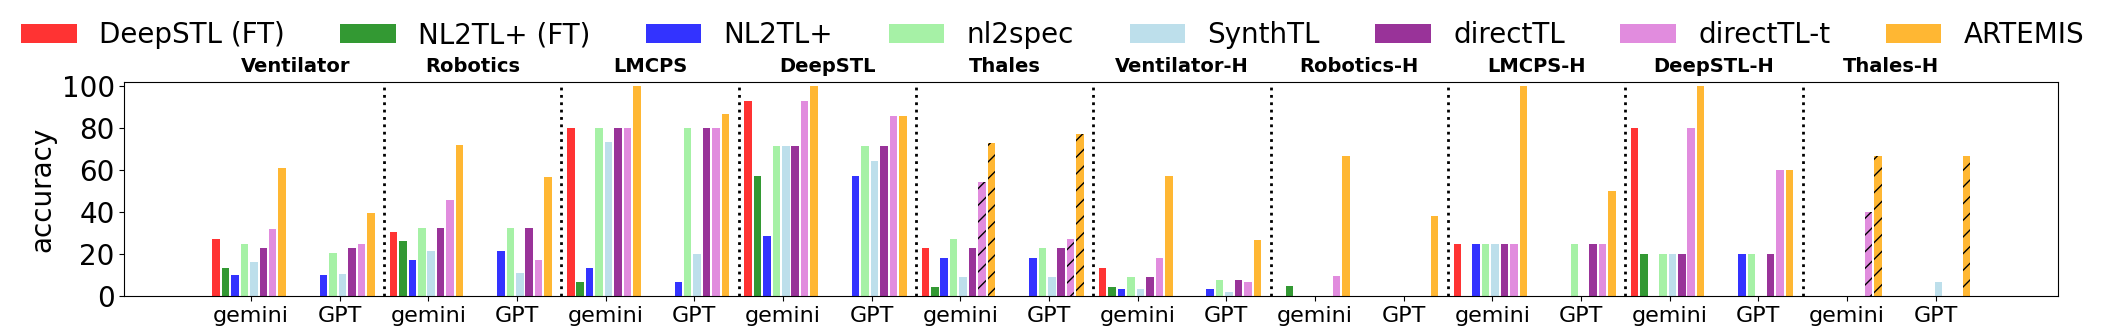

In [10]:
def plot_accuracy_data(all_data,colors,hatches,alpha,cur_pos=0):
    bars = []
    for data_group in all_data:
        group_start = cur_pos
        group_width = len(colors)*width + (len(colors)-1)*space
        for i, (score, color,hatch) in enumerate(zip(data_group, colors, hatches)):
            bar = plt.bar(cur_pos + i*width + (i-1)*space, 100*score, color=color,hatch=hatch,width=width,align='center',alpha=alpha)
            bars.append(bar)
        cur_pos += len(colors)*width + (len(colors)-1)*space
        cur_pos += group_space
    return cur_pos,bars

def plot_model_group_names(centres):
    ax = plt.gca()
    
    group_labels  = ["Ventilator", "Robotics", "LMCPS", "DeepSTL", "Thales"]
    group_labels += [f"{entry}-H" for entry in group_labels]
    assert len(group_labels)*len(model_list) == len(centres)
    group_centres = []
    for i in range(len(group_labels)):
        cur_centre = (centres[i*len(model_list)] + centres[i*len(model_list)+1])/2
        group_centres.append(cur_centre)
        if i != 0:
            plt.axvline(x=(cur_centre+prev_centre)/2,color="black", linestyle=":", linewidth=2)
        prev_centre = cur_centre
    ymax = ax.get_ylim()[1]              # current top of y-axis
    for x, label in zip(group_centres, group_labels):
        plt.text(x, ymax*1.0, label,      # *1.02 moves it a bit above the plot
                ha='center', va='bottom',
                fontsize=14, fontweight='bold')
    #ax2 = ax.twiny()                 # ax = the axis that holds the bars
    #ax2.set_xlim(ax.get_xlim())
    
    #ax2.set_xticks(group_centres)
    #ax2.set_xticklabels(group_labels, fontsize=16)
    
    #ax2.tick_params(axis='x', which='major',
    #                pad=10,          # distance from the plot
    #                length=0)        # no tick marks
    
    #for spine in ax2.spines.values():   # erase the frame lines of ax2
    #    spine.set_visible(False)

plt.figure(figsize=(20, 3))

cur_pos,bars = plot_accuracy_data(all_fret_data,colors,hatches,alpha=0.8)
cur_pos,_ = plot_accuracy_data(all_psp_data,colors,psp_hatches,alpha=0.8,cur_pos=cur_pos)

cur_pos,_ = plot_accuracy_data(all_hard_fret_data,colors,hatches,alpha=0.8,cur_pos=cur_pos)
cur_pos,_ = plot_accuracy_data(all_hard_psp_data,colors,psp_hatches,alpha=0.8,cur_pos=cur_pos)

# Remove x-axis labels
#plt.xticks([])
centres = []
group_start = 0
num_groups = 10
model_names = ["gemini","GPT"]
for i in range(num_groups*len(model_names)):
    group_width = len(colors)*width + (len(colors)-1)*space
    centre = group_start + (group_width - width) / 2
    centres.append(centre)
    group_start += group_width
    group_start += group_space
plt.xticks(centres,model_names*num_groups,fontsize=16)

plot_model_group_names(centres)

#plot_div_lines(centres)

# Axis labels and limits
#plt.ylabel("Equivalence Score")
plt.ylim(0, 1.02*100)
#plt.title("Equivalence of Methods")
plt.tight_layout()
plt.yticks(fontsize=20)
# Add legend
plt.legend([bar[0] for bar in bars], plot_method_names,loc='upper center', bbox_to_anchor=(0.48, 1.4), ncol=9, frameon=False,fontsize=20)
#plt.show()
plt.ylabel("accuracy",fontsize=20)

# traces

In [11]:
dataset_names = [
    ("fretish_results","FSM?-AP",[i for i in range(9)]),
    ("fretish_results","FSM-S",[i for i in range(4)]),
    ("fretish_results","Ventilator",[i for i in range(121)]),
    ("fretish_results","REG",[i for i in range(2)]),
    ("fretish_results","RobotExplain",[i for i in range(46)]),
    ("fretish_results","deepstl-test",[i for i in range(14)]),
    ("PSP_results","Thales",[i for i in range(22)]),
]

In [12]:
num_trial = 50
model="gemini-2.5-flash"

In [13]:
cur_method = "nl2structnl-reflect"
modes = [None]

In [14]:
dist_methods = ["ltltalk","abstract"]

In [15]:
all_data = []
count = 0
for result_dir,cur_dataset_name, row_idx_list in dataset_names:
    for cur_mode in modes:
        for row_idx in row_idx_list:
            try:
                cur_ex_list = []
                for dist_method in dist_methods:
                    cur_exp_name = f"{result_dir}/{cur_dataset_name}-{row_idx}_model-{model}_trials-{num_trial}"
                    if cur_mode == "extra":
                        save_name = cur_mode + "_" + cur_method + "_" + dist_method
                    else:
                        save_name = cur_method + "_" + dist_method
                    with open(cur_exp_name+f"_{save_name}"+"_traces.json", "r") as json_file:
                        data = json.load(json_file)
                    cur_ex_list.append(data)
                all_data.append(cur_ex_list)
            except:
                count += 1
                #print(cur_dataset_name,row_idx,cur_method,dist_method)

In [16]:
all_num_traces = [[] for entry in dist_methods]
all_var_count = [[] for entry in dist_methods]
all_tracesizes = [[] for entry in dist_methods]
all_tracegen_times = [[] for entry in dist_methods]
all_num_f = []
for i in range(len(all_data)):
    for j in range(len(all_data[i])):
        method_metrics = all_data[i][j]
        num_traces = method_metrics[0]
        var_counts = method_metrics[1]
        tracesizes = method_metrics[2]
        balanced = method_metrics[3]
        trace_gen_times = method_metrics[4]
        """
        num_traces = [method_metrics[0][0]]
        var_counts = [method_metrics[1][0]]
        tracesizes = [method_metrics[2][0]]
        balanced = [method_metrics[3][0]]
        trace_gen_times = [method_metrics[4][0]]
        """
        #print(num_traces[0])
        #print(balanced[0][0][1])
        #print(trace_gen_times[0])
        #print(len(trace_gen_times[0]))
        if dist_methods[j] == "ltltalk":
            #print(balanced,num_traces)
            all_num_f += [balanced[0][0][1] for entry in num_traces]
        all_num_traces[j] += num_traces
        #for lst in var_counts:
        #    all_var_count[j] += lst
        all_var_count[j] += [np.mean(lst) for lst in var_counts]
        for lst in tracesizes:
            all_tracesizes[j] += lst
        #all_tracesizes[j] += [np.mean(lst) for lst in tracesizes]
        all_tracegen_times[j] += trace_gen_times[0]
all_num_traces = np.array(all_num_traces)
all_var_count = np.array(all_var_count)
#all_tracesizes = np.array(all_tracesizes)

In [17]:
data_arr = all_num_traces

(0.0, 100.0)

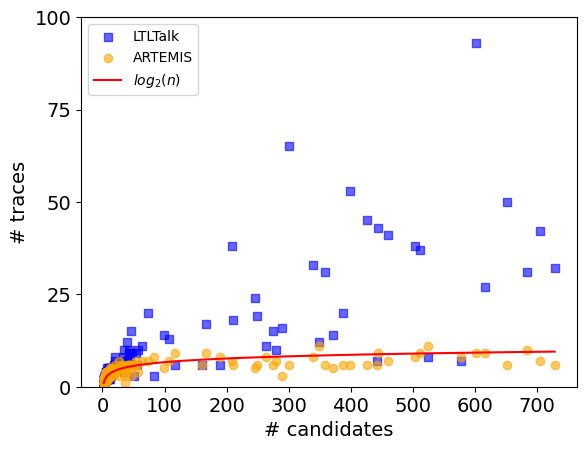

In [18]:
import matplotlib.pyplot as plt
fontsize =14
#plt.figure(figsize=(6, 1.2))

method_names = ["LTLTalk","ARTEMIS"]
colors = ["blue","orange","red"]
markers =["s","o"]
for i in range(len(data_arr)):
    plt.scatter(all_num_f, data_arr[i],label=method_names[i],color=colors[i],marker=markers[i],alpha=0.6)

n_range = [n for n in range(np.min(all_num_f),np.max(all_num_f)+1)]
log_line = [np.log2(n) for n in n_range]
plt.plot(n_range,log_line,label="$log_2(n)$",color=colors[-1])

# Add labels and title
plt.xlabel('# candidates',fontsize=fontsize)
plt.ylabel('# traces',fontsize=fontsize)
#plt.title('Simple Scatter Plot')
plt.yticks([0,25,50,75,100],fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.legend()
#plt.legend(loc='upper center', #bbox_to_anchor=(0.5, 1.45), 
#           ncol=3, frameon=False,fontsize=fontsize)

plt.ylim([0,100])